In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [50]:
N = 2
L = 20
beta_list = np.arange(5,21)/10
alpha = 0.5

time_list = []
obs = {"E": [],"mag_sus":[], "w_U": [], "w_z": [], "topo_sus_U": [], "topo_sus_z": []}
for beta in beta_list:
    filename = f'data/data_N{N}_L{L}/stats_N{N}_L{L}_beta{beta}_alpha{alpha}.npy'
    data = np.load(filename, allow_pickle=True).item()
    time_list.append([data["runtime_True"], data["runtime_False"]])
    for key, obs_True in data["stats_True"].items():
        obs_False = data["stats_False"][key]
        obs[key].append([[obs_True["mean"], obs_True["tau"], obs_True["error"]], [obs_False["mean"], obs_False["tau"], obs_False["error"]]])
time_list = np.asarray(time_list)
for key in obs.keys():
    obs[key] = np.asarray(obs[key])

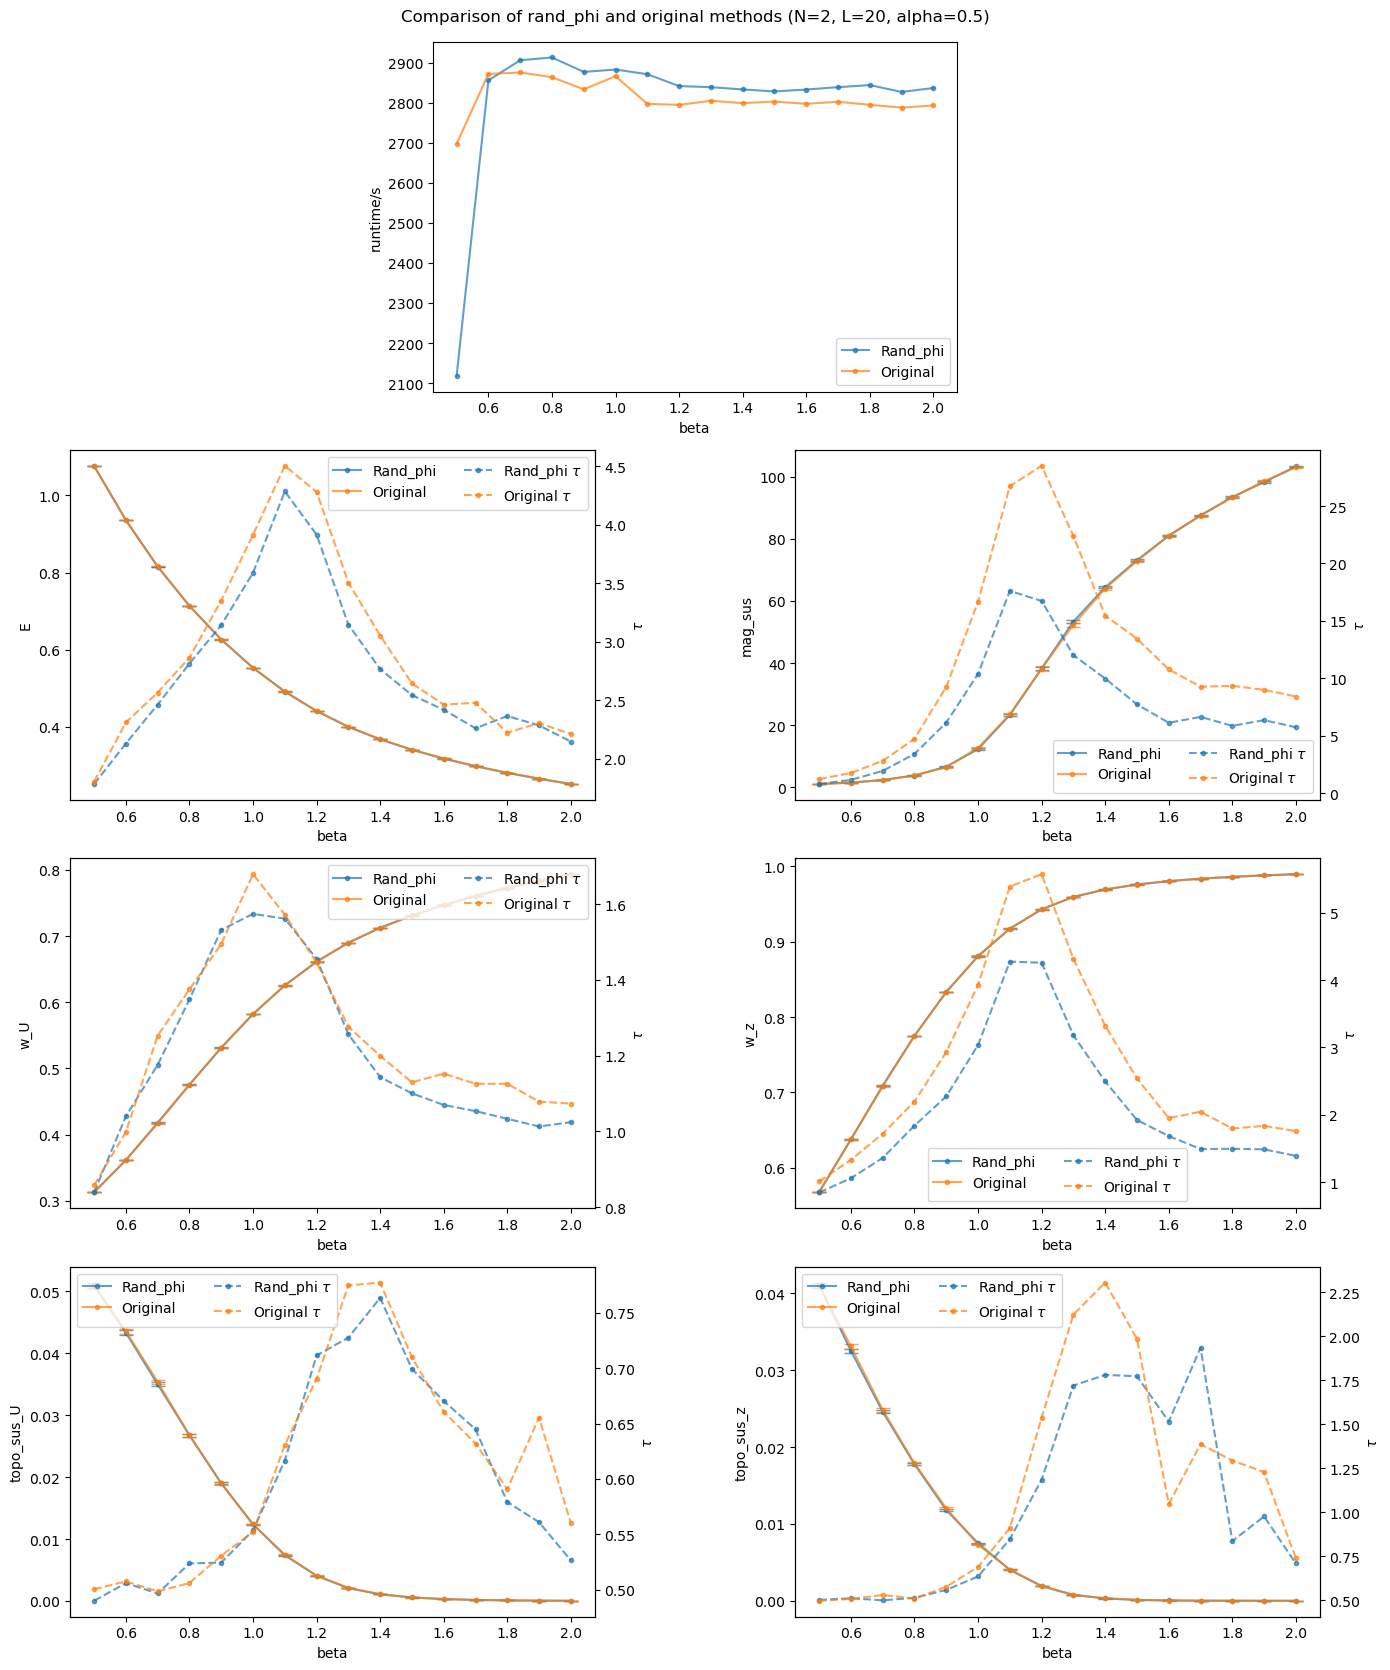

In [ ]:
plt.figure(figsize=(14, 17))
col = 5 # must be odd
row = 3
gap = 1

ax = plt.subplot2grid((4*row, 2*col+gap), (0, col//2 + gap//2 + 1), colspan=col, rowspan=row)
ax.plot(beta_list, time_list[:,0], marker=".", label="Rand_phi", alpha=0.7)
ax.plot(beta_list, time_list[:,1], marker=".", label="Original", alpha=0.7)
ax.legend()
ax.set_xlabel("beta")
ax.set_ylabel("runtime/s")
ax.set_title(" ")

i = 2
for key, data in obs.items():
    ax = plt.subplot2grid((4*row, 2*col+gap), (row * (i//2), col * (i%2) + gap * (i%2)), colspan=col, rowspan=row)
    line1 = ax.errorbar(beta_list, data[:,0,0], yerr=data[:,0,2], capsize=5, marker=".", label="Rand_phi", alpha=0.7)
    line2 = ax.errorbar(beta_list, data[:,1,0], yerr=data[:,1,2], capsize=5, marker=".", label="Original", alpha=0.7)
    ax.set_xlabel("beta")
    ax.set_ylabel(key)

    ax1 = ax.twinx()
    line3 = ax1.plot(beta_list, data[:,0,1], marker=".", label="Rand_phi tau", alpha=0.7, linestyle="--")
    line4 = ax1.plot(beta_list, data[:,1,1], marker=".", label="Original tau", alpha=0.7, linestyle="--")
    ax1.set_ylabel(r"$\tau$")

    handles = [line1[0], line2[0], line3[0], line4[0]]
    labels = ["Rand_phi", "Original", "Rand_phi "+r"$\tau$", "Original "+r"$\tau$"]
    ax1.legend(handles, labels, ncol=2)
    
    i += 1

plt.suptitle(f"Comparison of rand_phi and original methods (N={N}, L={L}, alpha={alpha})")
plt.tight_layout()
plt.savefig(f"figures/compare_N{N}_L{L}_alpha{alpha}.png", dpi=400)
plt.show()